# Tests with one agent only

In [1]:
# The tests are particularly interesting with Watts-Strogatz networks
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mesa

# Set a seed
np.random.seed(666)

# Plotting settings

from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': 'orange',
    
    'Neutral': 'blue',
    'Pro - environment': 'green'
}

from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel

In [2]:
# Initial tests
all_agents_game = statusgame_model(N=100, seed=666, lambda_s=1, memory=15,
        create_network="watts_strogatz", p=1/10, gamma=0.4, k=20, rho=1/3, seed_consumption=True)

one_agent_game = OneActiveStatusGameModel(N=100, one_active_agent_id=2, seed=666, lambda_s=1, memory=20,
        create_network="watts_strogatz", p=1/10, gamma=0.4, k=20, rho=1/3, seed_consumption=True)


In [3]:
# Run the models
for _ in range(70):
    all_agents_game.step()
    one_agent_game.step()

# Collect dataframes
all_agents_df = all_agents_game.datacollector.get_agent_vars_dataframe().reset_index()
one_agent_df = one_agent_game.datacollector.get_agent_vars_dataframe().reset_index()

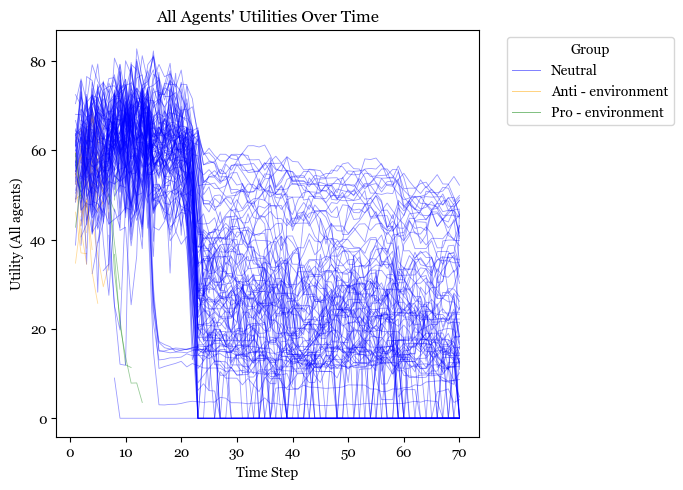

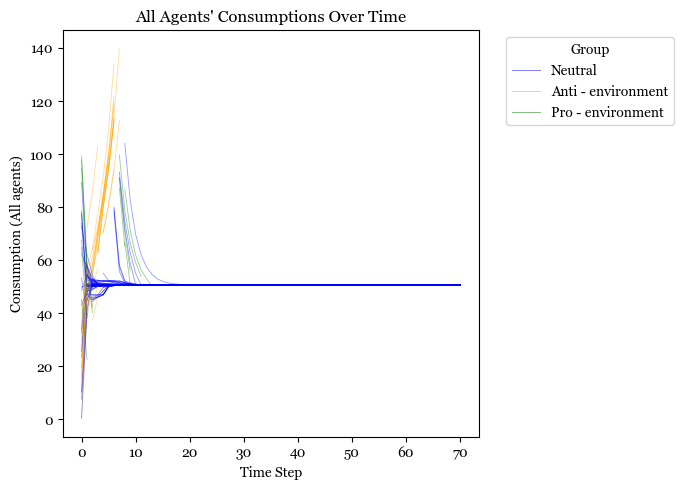

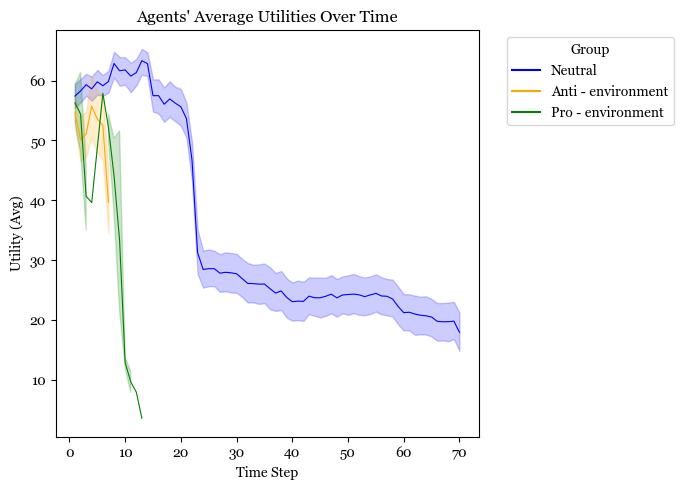

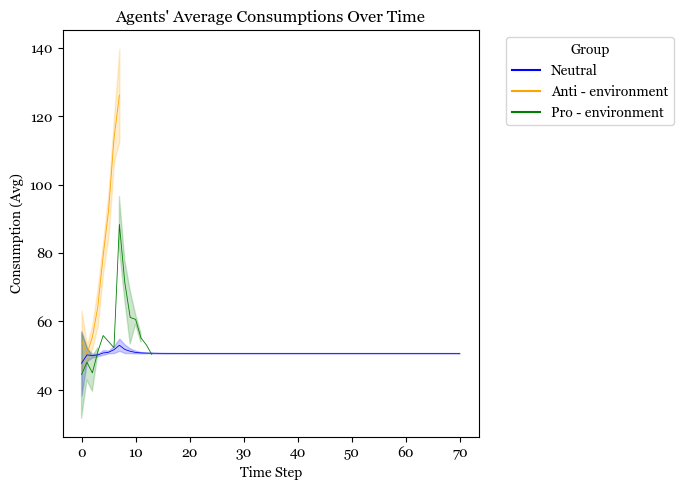

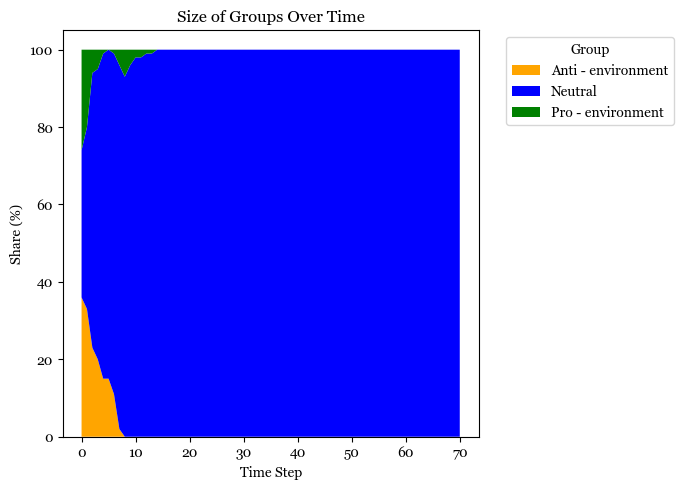

In [4]:
# Plots
plot_all_agent_graphs(all_agents_df, color_dict, output_folder="plots/all", show_plots=True)

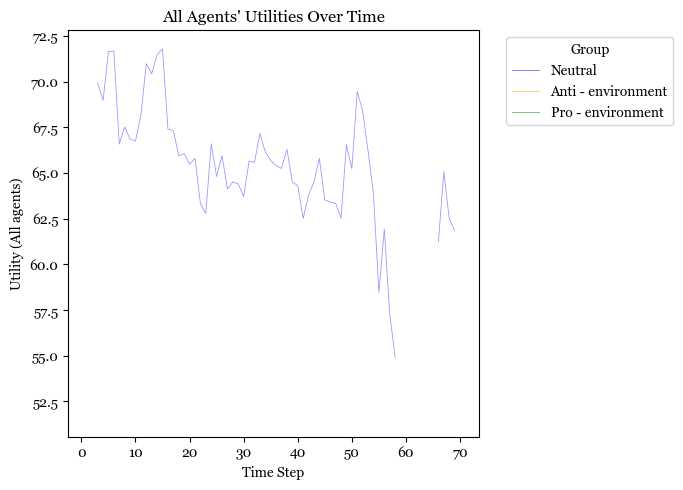

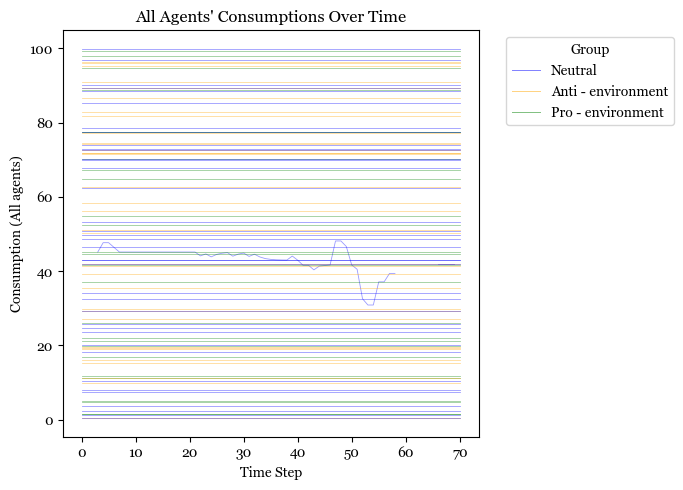

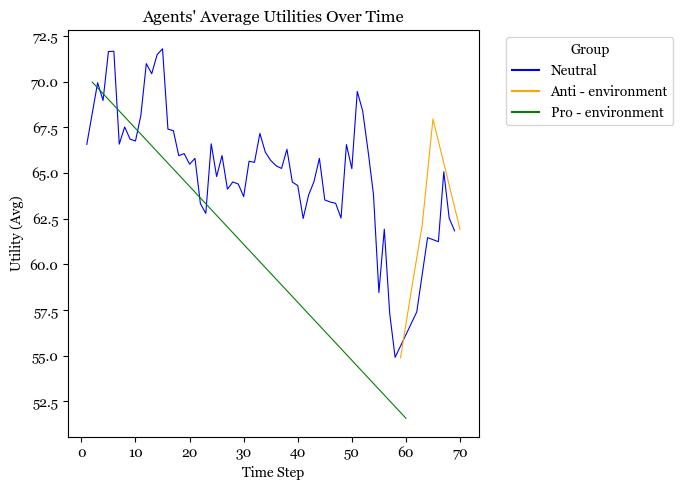

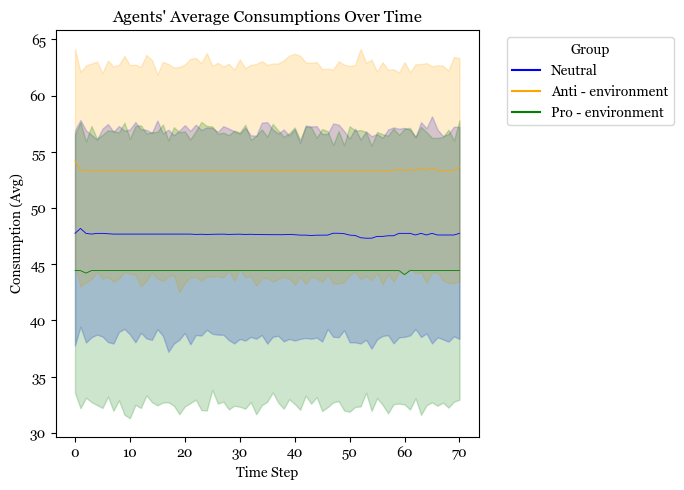

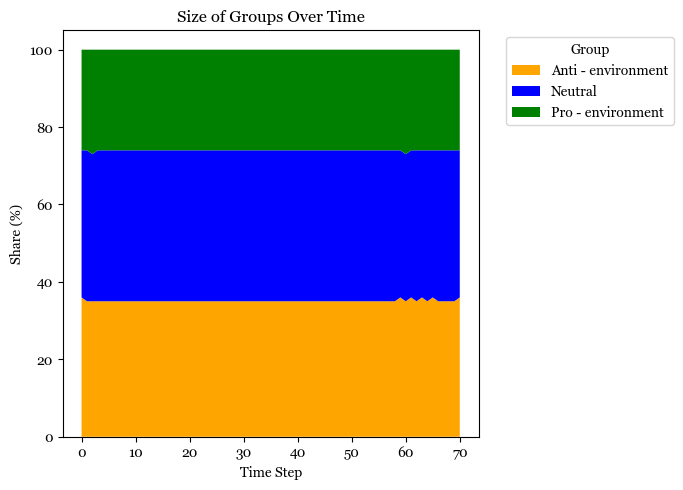

In [5]:
#Plots one agent
plot_all_agent_graphs(one_agent_df, color_dict, output_folder="plots/one", show_plots=True)

In [6]:
timeline_1 = one_agent_df.loc[one_agent_df["AgentID"] == 2]

In [7]:
timeline_1

,Step,AgentID,group,avg_common,status,field_of_action,consumption,utility,belief_min,belief_median,belief_max,u_pro,u_anti,u_neutral,status_pro,status_anti,status_neutral
1,0,2,Anti - environment,NaN,NaN,NaN,84.418664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,1,2,Neutral,11.700000,39.417208,33.259338,64.750149,66.568092,1.270320,64.750149,99.879467,65.532918,15.051948,66.568092,65.532918,15.051948,66.568092
201,2,2,Pro - environment,11.476190,68.064515,25.391932,38.358217,69.977027,1.270320,57.469750,99.879467,69.977027,37.907172,65.215360,69.977027,37.907172,65.215360
301,3,2,Neutral,11.636364,67.205087,24.608500,45.154055,69.940353,1.270320,45.154055,99.879467,59.133953,67.420553,69.940353,59.133953,67.420553,69.940353
401,4,2,Neutral,11.695652,69.925105,21.890165,47.671703,68.969195,1.270320,47.671703,99.879467,60.642920,55.890975,68.969195,60.642920,55.890975,68.969195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6601,66,2,Neutral,8.900000,63.567100,23.312696,42.005486,61.239268,3.643288,42.005486,89.304339,54.804654,53.851190,61.239268,54.804654,53.851190,61.239268
6701,67,2,Neutral,8.500000,65.061508,18.919541,42.005486,65.061508,3.643288,42.005486,89.304339,52.558261,63.058622,65.061508,52.558261,63.058622,65.061508
6801,68,2,Neutral,8.000000,62.521014,18.919541,42.005486,62.521014,3.643288,42.005486,89.304339,52.657648,60.411977,62.521014,52.657648,60.411977,62.521014
6901,69,2,Neutral,8.400000,61.832341,18.919541,42.005486,61.832341,3.643288,42.005486,89.304339,48.128968,60.700397,61.832341,48.128968,60.700397,61.832341


In [ ]:
# Batch run to look at avg friends in common
# Now, test on only one agent
params = {"seed": 666, 
          "alpha": np.linspace(0.001, 1, 20),
          'N':[100],
          "gamma": [0.1], 
          "create_network": "watts_strogatz", 
          "k": [20], 
          "p": [1/10],
          "rho": 1/3, 
          "one_active_agent_id": [2], 
          "seed_consumption": True, 
          "memory": [20]}

results_batch = mesa.batch_run(
    OneActiveStatusGameModel,
    parameters=params,
    iterations=5,
    max_steps=200,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

results_batch_df = pd.DataFrame(results_batch)
results_batch_df.to_csv("results_batch_gammaconstant_0_to_1_one_agent.csv")

  0%|          | 0/100 [00:00<?, ?it/s]

In [32]:
results_avg_common = results_batch_df.loc[results_batch_df["AgentID"] == 2]

<Axes: xlabel='alpha', ylabel='avg_common'>

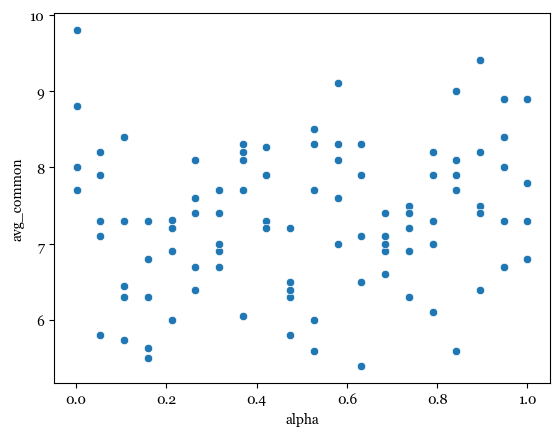

In [33]:
sns.scatterplot(data=results_avg_common, x="alpha", y="avg_common")

In [14]:
results_avg_common.alpha.value_counts().sort_index()

0.010000    5
0.062105    5
0.114211    5
0.166316    5
0.218421    5
0.270526    5
0.322632    5
0.374737    5
0.426842    5
0.478947    5
0.531053    5
0.583158    5
0.635263    5
0.687368    5
0.739474    5
0.791579    5
0.843684    5
0.895789    5
0.947895    5
1.000000    5
Name: alpha, dtype: int64

In [8]:
# Data for multiple tests / agents
# Create lists for each group
ids_anti = all_agents_df.loc[(all_agents_df["Step"] == 0) & (all_agents_df["group"] == "Anti - environment")]["AgentID"].tolist()
ids_neutral = all_agents_df.loc[(all_agents_df["Step"] == 0) & (all_agents_df["group"] == "Neutral")]["AgentID"].tolist()
ids_pro = all_agents_df.loc[(all_agents_df["Step"] == 0) & (all_agents_df["group"] == "Pro - environment")]["AgentID"].tolist()

In [9]:
# First, test on all agents changing gamma 
# Change only gamma / k
params = {"seed": 666, 
          'N':[250],
          "gamma": np.linspace(0.01, 1, 10), 
          "create_network": "watts_strogatz", 
          "k": [5, 10, 20, 40, 80], 
          "p": [1/10],
          "rho": 1/3, 
          "seed_consumption": True}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=5,
    max_steps=100,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

results_batch_df = pd.DataFrame(results_batch)
results_batch_df.to_csv("results_batch_gammaconstant_0_to_1.csv")


  0%|          | 0/250 [00:00<?, ?it/s]

Process SpawnPoolWorker-7:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-3:
Process SpawnPoolWorker-6:
Process SpawnPoolWorker-8:
Process SpawnPoolWorker-1:


KeyboardInterrupt: 

In [ ]:
# Now, test on only one agent
params = {"seed": 666, 
          'N':[250],
          "gamma": np.linspace(0.01, 1, 10), 
          "create_network": "watts_strogatz", 
          "k": [5, 10, 20, 40, 80], 
          "p": [1/10],
          "rho": 1/3, 
          "one_active_agent_id": ids_pro[0:20], 
          "seed_consumption": True}

results_batch = mesa.batch_run(
    OneActiveStatusGameModel,
    parameters=params,
    iterations=1,
    max_steps=100,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

results_batch_df = pd.DataFrame(results_batch)
results_batch_df.to_csv("results_batch_gammaconstant_0_to_1_one_agent.csv")

  0%|          | 0/1000 [00:00<?, ?it/s]